<a href="https://colab.research.google.com/github/aryanp2107/100-ML-Projects/blob/main/Day61_AP(Segmentation).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Install dependencies
!pip install segmentation-models-pytorch -q
!pip install albumentations -q
!pip install  ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import json
import time
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

import albumentations as A
from albumentations.pytorch import ToTensorV2

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Using device: cuda


In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Paths
SAVE_PATH = '/content/drive/MyDrive/100-days-of-ml/capstone-autonomous-perception'
os.makedirs(SAVE_PATH, exist_ok=True)

print(f"Save path: {SAVE_PATH}")

Mounted at /content/drive
Save path: /content/drive/MyDrive/100-days-of-ml/capstone-autonomous-perception


In [17]:
detection_model_path = f"{SAVE_PATH}/rtdetr_s_bdd100k_training/weights/best.pt"

if os.path.exists(detection_model_path):
    print(f"✓ Detection model found: {detection_model_path}")
    DETECTION_AVAILABLE = True
else:
    print("Detection model not found - fusion preview will be skipped")
    DETECTION_AVAILABLE = False

✓ Detection model found: /content/drive/MyDrive/100-days-of-ml/capstone-autonomous-perception/rtdetr_s_bdd100k_training/weights/best.pt


In [ ]:
"""
Drivable Area Segmentation

Goal: To identify where the car CAN drive vs. where it CANNOT

BDD100K Drivable Area Classes:
  • Direct drivable (your lane)
  • Alternative drivable (other lanes you could use)
  • Not drivable (everything else)

We'll display a binary: 0-drivable vs (1)- not drivable

"""


In [18]:
SEG_DATASET_PATH = f"{SAVE_PATH}/bdd100k-drivable"

if os.path.exists(f"{SEG_DATASET_PATH}/train"):
    print("Drivable area dataset already exists!")
else:
    print("Setting up drivable area dataset...")
    os.makedirs(SEG_DATASET_PATH, exist_ok=True)

Setting up drivable area dataset...


In [26]:
# Direct download - no Roboflow needed
!wget -q https://github.com/alexgkendall/SegNet-Tutorial/archive/refs/heads/master.zip -O /content/segnet.zip
!unzip -q /content/segnet.zip -d /content/

SEG_DATASET_PATH = '/content/SegNet-Tutorial-master/CamVid'
TRAIN_IMG_DIR = f"{SEG_DATASET_PATH}/train"
TRAIN_MASK_DIR = f"{SEG_DATASET_PATH}/trainannot"

print("Dataset ready!")
!ls {TRAIN_IMG_DIR} | head -5

Dataset ready!
0001TP_006690.png
0001TP_006720.png
0001TP_006750.png
0001TP_006780.png
0001TP_006810.png


In [27]:
print(f"\nDataset path: {SEG_DATASET_PATH}")
print("\nContents:")
!ls -la {SEG_DATASET_PATH}


Dataset path: /content/SegNet-Tutorial-master/CamVid

Contents:
total 144
drwxr-xr-x 8 root root  4096 Aug 13  2018 .
drwxr-xr-x 7 root root  4096 Aug 13  2018 ..
drwxr-xr-x 2 root root 12288 Aug 13  2018 test
drwxr-xr-x 2 root root 12288 Aug 13  2018 testannot
-rw-r--r-- 1 root root 19215 Aug 13  2018 test.txt
drwxr-xr-x 2 root root 20480 Aug 13  2018 train
drwxr-xr-x 2 root root 20480 Aug 13  2018 trainannot
-rw-r--r-- 1 root root 30053 Aug 13  2018 train.txt
drwxr-xr-x 2 root root  4096 Aug 13  2018 val
drwxr-xr-x 2 root root  4096 Aug 13  2018 valannot
-rw-r--r-- 1 root root  7777 Aug 13  2018 val.txt


In [30]:
# Count samples
if TRAIN_IMG_DIR:
    train_images = sorted(glob.glob(f"{TRAIN_IMG_DIR}/*.png") + glob.glob(f"{TRAIN_IMG_DIR}/*.jpg"))
    print(f"Found {len(train_images)} training images")

if TRAIN_MASK_DIR:
    train_masks = sorted(glob.glob(f"{TRAIN_MASK_DIR}/*.png") + glob.glob(f"{TRAIN_MASK_DIR}/*.jpg"))
    print(f"Found {len(train_masks)} training masks")

Found 367 training images
Found 367 training masks


In [31]:
def find_dataset_paths(base_path):
    """Auto-detect dataset structure"""
    possible_image_dirs = ['train/images', 'train', 'images', 'train_images']
    possible_mask_dirs = ['train/masks', 'train_labels', 'masks', 'train_masks', 'trainannot']

    image_dir = None
    mask_dir = None

    for d in possible_image_dirs:
        path = os.path.join(base_path, d)
        if os.path.exists(path):
            files = os.listdir(path)
            if any(f.endswith(('.jpg', '.png')) for f in files):
                image_dir = path
                break

    for d in possible_mask_dirs:
        path = os.path.join(base_path, d)
        if os.path.exists(path):
            mask_dir = path
            break

    return image_dir, mask_dir

TRAIN_IMG_DIR, TRAIN_MASK_DIR = find_dataset_paths(SEG_DATASET_PATH)

print(f"Image directory: {TRAIN_IMG_DIR}")
print(f"Mask directory: {TRAIN_MASK_DIR}")

Image directory: /content/SegNet-Tutorial-master/CamVid/train
Mask directory: /content/SegNet-Tutorial-master/CamVid/trainannot


Exploring the Dataset

In [39]:
def visualize_segmentation_sample(image_path, mask_path):
    """Visualize image and its segmentation mask"""
    img = np.array(Image.open(image_path).convert('RGB'))
    mask = np.array(Image.open(mask_path))

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original image
    axes[0].imshow(img)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    # Mask
    axes[1].imshow(mask, cmap='tab20')
    axes[1].set_title(f'Segmentation Mask\nUnique values: {np.unique(mask)}')
    axes[1].axis('off')

    # Overlay
    overlay = img.copy()
    # Create colored overlay for drivable area
    if mask.max() > 0:
        drivable_mask = mask > 0  # Binary: any class > 0 is drivable
        overlay[drivable_mask] = overlay[drivable_mask] * 0.5 + np.array([0, 255, 0]) * 0.5

    axes[2].imshow(overlay.astype(np.uint8))
    axes[2].set_title('Overlay (Green = Drivable)')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()


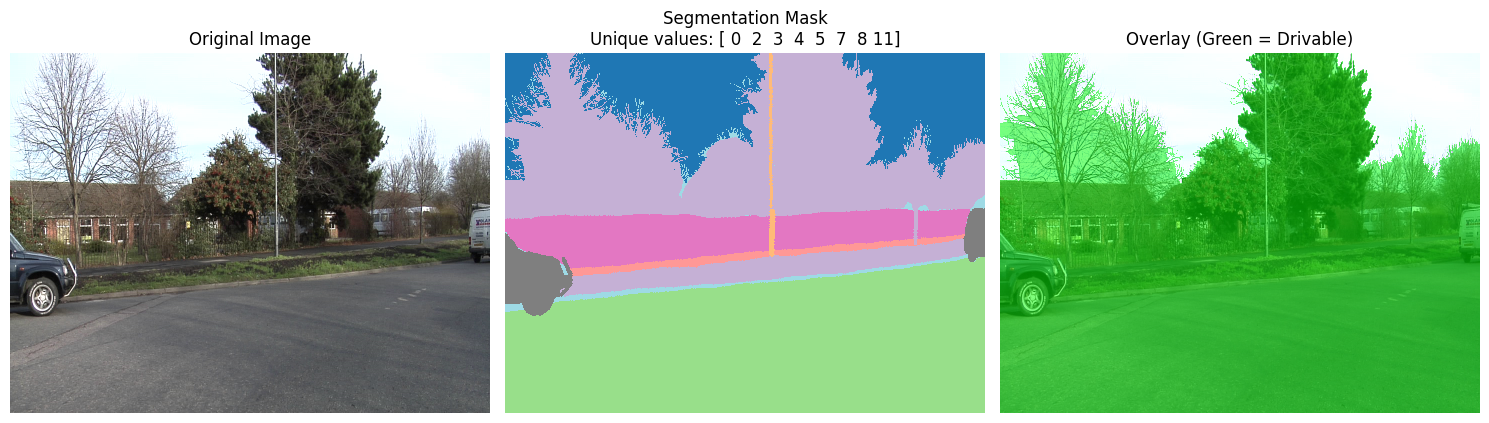

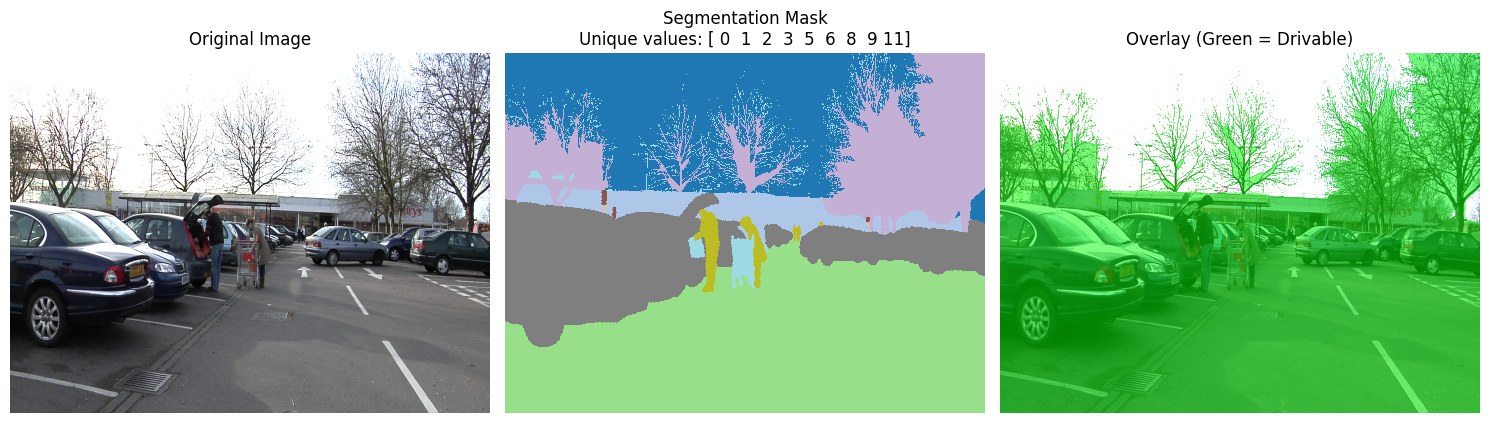

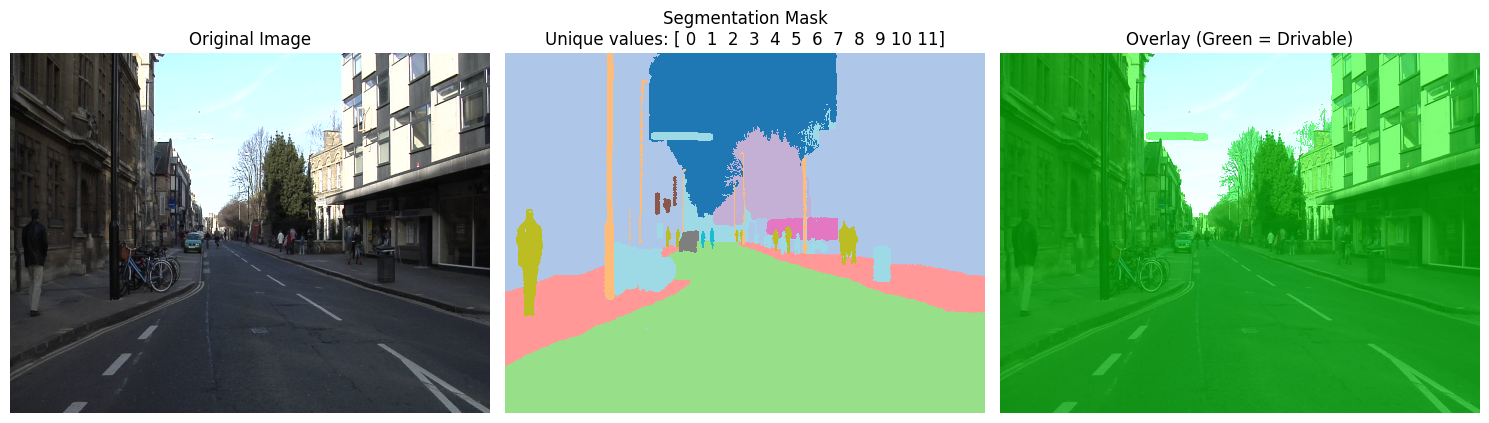

In [40]:
# Show random samples
if train_images and train_masks:
    for i in np.random.choice(len(train_images), min(3, len(train_images)), replace=False):
        img_path = train_images[i]

        # Find corresponding mask
        img_name = os.path.basename(img_path)
        mask_name = img_name.replace('.jpg', '.png')  # Masks are usually PNG
        mask_path = os.path.join(TRAIN_MASK_DIR, mask_name)

        # Try alternative naming conventions
        if not os.path.exists(mask_path):
            mask_path = os.path.join(TRAIN_MASK_DIR, img_name)
        if not os.path.exists(mask_path):
            mask_path = train_masks[i] if i < len(train_masks) else None

        if mask_path and os.path.exists(mask_path):
            visualize_segmentation_sample(img_path, mask_path)
        else:
            print(f"Mask not found for {img_name}")

In [41]:
if train_masks:
    sample_mask = np.array(Image.open(train_masks[0]))

    print("Mask Analysis:")
    print(f"  Shape: {sample_mask.shape}")
    print(f"  Dtype: {sample_mask.dtype}")
    print(f"  Unique values: {np.unique(sample_mask)}")
    print(f"  Min: {sample_mask.min()}, Max: {sample_mask.max()}")

    # Value distribution
    print("\nPixel distribution:")
    for val in np.unique(sample_mask):
        count = (sample_mask == val).sum()
        pct = count / sample_mask.size * 100
        print(f"  Class {val}: {count:,} pixels ({pct:.1f}%)")

Mask Analysis:
  Shape: (360, 480)
  Dtype: uint8
  Unique values: [ 0  1  2  3  4  5  6  8  9 11]
  Min: 0, Max: 11

Pixel distribution:
  Class 0: 23,726 pixels (13.7%)
  Class 1: 64,726 pixels (37.5%)
  Class 2: 1,904 pixels (1.1%)
  Class 3: 16,139 pixels (9.3%)
  Class 4: 11,897 pixels (6.9%)
  Class 5: 2,303 pixels (1.3%)
  Class 6: 2,543 pixels (1.5%)
  Class 8: 40,851 pixels (23.6%)
  Class 9: 731 pixels (0.4%)
  Class 11: 7,980 pixels (4.6%)


Dataset Class

In [44]:
class DrivableAreaDataset(Dataset):
  """ Dataset for drivable area segmentation """
  def __init__(self, image_dir, mask_dir, transform=None, img_size=256):
    self.image_dir = image_dir
    self.mask_dir = mask_dir
    self.transform = transform
    self.img_size = img_size

    self.images = sorted(
        glob.glob(f"{image_dir}/*.png") +
        glob.glob(f"{image_dir}/*.jpg")
    )

    print(f"Found {len(self.images)} images")

  def __len__(self):
    return len(self.images)

  def __getitem__(self, idx):
    #loading the image
    img_path = self.images(Image.open(img_path).convert("RGB"))

    img_name = os.path.basename(img_path)
    mask_name = img_name.replace('.jpg', '.png')
    mask_path = os.path.join(self.mask_dir, mask_name)

    if not os.path.exists(mask_path):
      mask_path = os.path.join(self.mask_dir, img_name)
    if os.path.exists(mask_path):
      mask = np.array(Image.open(mask_path))

    else:
      #create an empty mask if not found
      mask = np.zeros((self.img_size, self.img_size), dtype=np.uint8)

    #Convert to binary mask
    if mask.ndim == 3:
      mask = mask[:, :, 0]      #Taking the first channel if RGB

    mask = (mask == 7).astype(np.float32)

    #Applying Transform
    if self.transform is not None:
      transformed = self.transform(image=img, mask=mask)
      img = transformed["image"]
      mask = transformed["mask"]
    else:
      # Default resize
      image = Image.fromarray(image).resize((self.img_size, self.img_size))
      image = torch.tensor(np.array(image)).permute(2, 0, 1).float() / 255.0

      mask = Image.fromarray((mask * 255).astype(np.uint8)).resize(
          (self.img_size, self.img_size), Image.NEAREST
      )
      mask = torch.tensor(np.array(mask)).float() / 255.0

        # Ensure mask is 2D
      if mask.ndim == 3:
        mask = mask[0]
    return img, mask.unsqueeze(0)


In [47]:
IMG_SIZE = 256

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.45, 0.406], std=[0.229, 0.224, 0.2225]),
    ToTensorV2()
])

print(f"Image size: {IMG_SIZE} x {IMG_SIZE}")

Image size: 256 x 256


In [50]:
from sklearn.model_selection import train_test_split

all_images = sorted(glob.glob(f"{TRAIN_IMG_DIR}/*.png") + glob.glob(f"{TRAIN_IMG_DIR}/*.jpg"))
train_imgs, val_imgs = train_test_split(all_images, test_size=0.2, random_state=42)

print(f"Training set: {len(train_images)} images")
print(f"Validation set: {len(val_images)} images")


Training set: 293 images
Validation set: 74 images


In [51]:
# Custom dataset that takes list of image paths
class DrivableAreaDatasetFromList(Dataset):
    """Dataset from list of image paths"""

    def __init__(self, image_paths, mask_dir, transform=None, img_size=256):
        self.image_paths = image_paths
        self.mask_dir = mask_dir
        self.transform = transform
        self.img_size = img_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = np.array(Image.open(img_path).convert('RGB'))

        # Find mask
        img_name = os.path.basename(img_path)
        mask_name = img_name.replace('.jpg', '.png')
        mask_path = os.path.join(self.mask_dir, mask_name)

        if not os.path.exists(mask_path):
            mask_path = os.path.join(self.mask_dir, img_name)

        if os.path.exists(mask_path):
            mask = np.array(Image.open(mask_path))
        else:
            mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

        # Convert to binary
        if mask.ndim == 3:
            mask = mask[:, :, 0]
        mask = (mask > 0).astype(np.float32)

        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']

        if mask.ndim == 2:
            mask = mask.unsqueeze(0)

        return image, mask

# Create datasets
train_dataset = DrivableAreaDatasetFromList(train_imgs, TRAIN_MASK_DIR, train_transform, IMG_SIZE)
val_dataset = DrivableAreaDatasetFromList(val_imgs, TRAIN_MASK_DIR, val_transform, IMG_SIZE)

print(f"Train dataset: {len(train_dataset)} samples")
print(f"Val dataset: {len(val_dataset)} samples")

Train dataset: 293 samples
Val dataset: 74 samples


In [52]:
BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train loader: {len(train_loader)} batches")
print(f"Val loader: {len(val_loader)} batches")

Train loader: 19 batches
Val loader: 5 batches


In [53]:
# Verify batch
images, masks = next(iter(train_loader))
print(f"Image batch shape: {images.shape}")
print(f"Mask batch shape: {masks.shape}")
print(f"Mask unique values: {torch.unique(masks)}")

Image batch shape: torch.Size([16, 3, 256, 256])
Mask batch shape: torch.Size([16, 1, 256, 256])
Mask unique values: tensor([0., 1.])


U-NET Model

In [64]:
class DoubleConv(nn.Module):
  """Two consecutive conv layers with batch norm and ReLU activation"""
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.conv = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, 3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, 3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
    )

  def forward(self, x):
    return self.conv(x)

class Down(nn.Module):
  """ Downsampling: MaxPool + DoubleConv"""
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.down = nn.Sequential(
        nn.MaxPool2d(2),
        DoubleConv(in_channels, out_channels)
    )
  def forward(self, x):
    return self.down(x)

class Up(nn.Module):
  """ Upsampling: ConvTranspose + Skip connections + Doubleconv"""
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
    self.conv = DoubleConv(in_channels, out_channels)

  def forward(self, x1, x2):
    x1 = self.up(x1)

    #Handling the size mismatch
    diff_y = x2.size()[2] - x1.size()[2]
    diff_x = x2.size()[3] - x1.size()[3]
    x1 = nn.functional.pad(x1, [diff_x // 2, diff_x - diff_x // 2, diff_y // 2, diff_y - diff_y // 2])

    x = torch.cat([x2, x1], dim=1)
    return self.conv(x)

class UNet(nn.Module):
  """ A U-Net for Binary Segmentation"""
  def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
    super().__init__()

    #Encoder
    self.inc = DoubleConv(in_channels, features[0])
    self.down1 = Down(features[0], features[1])
    self.down2 = Down(features[1], features[2])
    self.down3 = Down(features[2], features[3])
    self.down4 = Down(features[3], features[3] * 2)

    #Decodeer
    self.up1 = Up(features[3] * 2, features[3])
    self.up2 = Up(features[2] * 2, features[2])
    self.up3 = Up(features[1] * 2, features[1])
    self.up4 = Up(features[0] * 2, features[0])

    #ouput
    self.outc = nn.Conv2d(features[0], out_channels, kernel_size=1)

  def forward(self, x):
    #encoder
    x1 = self.inc(x)
    x2 = self.down1(x1)
    x3 = self.down2(x2)
    x4 = self.down3(x3)
    x5 = self.down4(x4)

    # Decoder with skip
    x = self.up1(x5, x4)
    x = self.up2(x, x3)
    x = self.up3(x, x2)
    x = self.up4(x, x1)

    return self.outc(x)

print("U-Net defined")

U-Net defined


In [65]:
model = UNet(in_channels=3, out_channels=1).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 31043521
Trainable parameters: 31043521


In [66]:
# Test forward pass
test_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
test_output = model(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {test_output.shape}")

Input shape: torch.Size([1, 3, 256, 256])
Output shape: torch.Size([1, 1, 256, 256])


Loss Functions and metrics

In [69]:
class DiceLoss(nn.Module):
  """Using Dice Loss for segmentation"""
  def __init__(self, smooth=1e-6):
    super().__init__()
    self.smooth = smooth

  def forward(self, pred, target):
    pred = torch.sigmoid(pred)

    pred_flat = pred.view(-1)
    target_flat = target.view(-1)

    intersection = (pred_flat * target_flat).sum()
    dice = (2. * intersection + self.smooth) / (pred_flat.sum() + target_flat.sum() + self.smooth)

    return 1 - dice

class CombinedLoss(nn.Module):
  """A combination of BCE and Dice Loss"""
  def __init__(self, bce_weight=0.5, dice_weight=0.5):
    super().__init__()
    self.bce = nn.BCEWithLogitsLoss()
    self.dice = DiceLoss()
    self.bce_weight = bce_weight
    self.dice_weight = dice_weight

  def forward(self, pred, target):
    bce_loss  = self.bce(pred, target)
    dice_loss = self.dice(pred, target)
    return self.bce_weight * bce_loss + self.dice_weight * dice_loss

def calculate_iou(pred, target, threshold=0.5):
  """Calculate Intersection over Union (IoU)"""
  pred = (torch.sigmoid(pred) > threshold).float()

  intersection = (pred * target).sum()
  union = pred.sum() + target.sum() - intersection

  iou = (intersection + 1e-6) / (union + 1e-6)
  return iou.item()

def calculate_dice(pred, target, threshold=0.5):
  """Calculate Dice Coeff"""
  pred = (torch.sigmoid(pred) > threshold).float()

  intersection = (pred * target).sum()
  dice = (2. * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)
  return dice.item()

print("Loss functions defined")

Loss functions defined


In [73]:
criterion = CombinedLoss(bce_weight=0.5, dice_weight=0.5)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)


print("Training setup completed")


Training setup completed


Training Loop

In [75]:
SEGMENTATION_MODEL_PATH = f"{SAVE_PATH}/unet_drivable.pt"

if os.path.exists(SEGMENTATION_MODEL_PATH):
    print("Found existing segmentation model! Loading...")
    model.load_state_dict(torch.load(SEGMENTATION_MODEL_PATH, map_location=device))
    SKIP_TRAINING = True
else:
    print("No existing model found. Will train from scratch.")
    SKIP_TRAINING = False

No existing model found. Will train from scratch.


In [76]:
def train_epoch(mode, loader, criterion, optimizer, device):
  model.train()
  total_loss = 0
  total_iou = 0

  for images, masks in tqdm(loader, desc='Training', leave=False):
    images = images.to(device)
    masks = masks.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, masks)

    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    total_iou += calculate_iou(outputs, masks)

  return total_loss / len(loader), total_iou / len(loader)

def evaluate_epoch(model, loader, critertion, device):
  model.eval()
  total_loss = 0
  total_iou = 0
  total_dice = 0

  with torch.no_grad():
    for images, masks in tqdm(loader, desc='validating', leave=False):
      images = images.to(device)
      masks = masks.to(device)

      outputs = model(images)
      loss = criterion(outputs, masks)

      total_loss += loss.item()
      total_iou += calculate_iou(outputs, masks)
      total_dice += calculate_dice(outputs, masks)

  return total_loss / len(loader), total_iou / len(loader), total_dice / len(loader)

print("Training and validation functions defined")


Training and validation functions defined


In [77]:
EPOCHS = 30

In [78]:
if not SKIP_TRAINING:
  print("Starting training...")

  history = {
      'train_loss': [],
      'train_iou': [],
      'val_loss': [],
      'val_iou': [],
      'val_dice': []
  }
  best_val_iou = 0
  patience_counter = 0
  PATIENCE = 10

  for epoch in range(EPOCHS):
    train_loss, train_iou = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_iou, val_dice = evaluate_epoch(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_iou'].append(train_iou)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(val_loss)
    history['val_dice'].append(val_dice)

    #progress
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Train IoU: {train_iou:.4f}")
    print(f"  Val Loss: {val_loss:.4f} | Val IoU: {val_iou:.4f} | Val Dice: {val_dice:.4f}")

    #save the best model
    if val_iou > best_val_iou:
      best_val_iou = val_iou
      torch.save(model.state_dict(), SEGMENTATION_MODEL_PATH)
      print("Saved best model!")
      patience_counter = 0
    else:
      patience_counter += 1

    #early stopping
    if patience_counter >= PATIENCE:
      print(f"Early stopping at epoch {epoch+1}")
      break

    print()

  print("\nTraining complete")
  print(f"Best validation IoU: {best_val_iou:.4f}")
else:
  print("Skipping training. Model already exists.")


Starting training...


Epoch 1/30
  Train Loss: 0.3857 | Train IoU: 0.8195
  Val Loss: 0.4301 | Val IoU: 0.8266 | Val Dice: 0.9049
Saved best model!



Epoch 2/30
  Train Loss: 0.2688 | Train IoU: 0.9599
  Val Loss: 0.3134 | Val IoU: 0.9097 | Val Dice: 0.9527
Saved best model!



Epoch 3/30
  Train Loss: 0.2388 | Train IoU: 0.9685
  Val Loss: 0.2417 | Val IoU: 0.9703 | Val Dice: 0.9849
Saved best model!



Epoch 4/30
  Train Loss: 0.2216 | Train IoU: 0.9696
  Val Loss: 0.2143 | Val IoU: 0.9727 | Val Dice: 0.9862
Saved best model!



...

Epoch 22/30
  Train Loss: 0.1118 | Train IoU: 0.9803
  Val Loss: 0.1104 | Val IoU: 0.9806 | Val Dice: 0.9902



Epoch 23/30
  Train Loss: 0.1095 | Train IoU: 0.9787
  Val Loss: 0.1488 | Val IoU: 0.9333 | Val Dice: 0.9654



Epoch 24/30
  Train Loss: 0.1096 | Train IoU: 0.9763
  Val Loss: 0.1074 | Val IoU: 0.9762 | Val Dice: 0.9880



Epoch 25/30
  Train Loss: 0.1054 | Train IoU: 0.9776
  Val Loss: 0.1026 | Val IoU: 0.9803 | Val Dice: 0.9900



Epoch 26/30
  Train Loss: 0.1009 | Train IoU: 0.9800
  Val Loss: 0.1019 | Val IoU: 0.9783 | Val Dice: 0.9890
Early stopping at epoch 26

Training complete
Best validation IoU: 0.9813


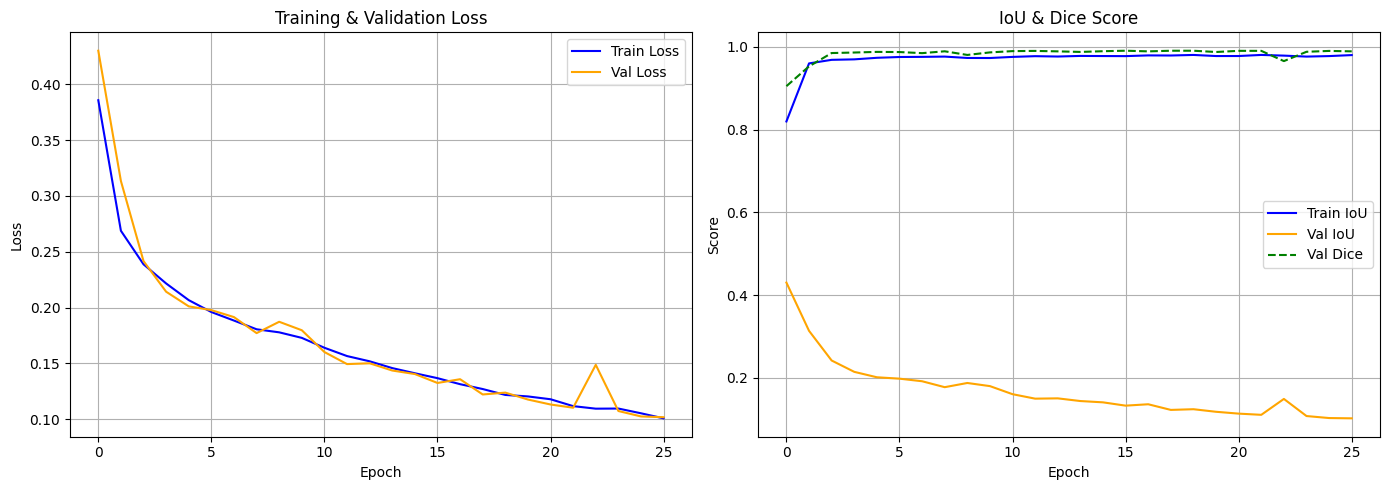

In [79]:
# Plot training history
if history:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
    axes[0].plot(history['val_loss'], label='Val Loss', color='orange')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training & Validation Loss')
    axes[0].legend()
    axes[0].grid(True)

    # IoU
    axes[1].plot(history['train_iou'], label='Train IoU', color='blue')
    axes[1].plot(history['val_iou'], label='Val IoU', color='orange')
    axes[1].plot(history['val_dice'], label='Val Dice', color='green', linestyle='--')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Score')
    axes[1].set_title('IoU & Dice Score')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

In [80]:
# Load best model
model.load_state_dict(torch.load(SEGMENTATION_MODEL_PATH, map_location=device))
model.eval()
print("Best model loaded!")

Best model loaded!


Evaluating the model

In [82]:
val_loss, val_iou, val_dice = evaluate_epoch(model, val_loader, criterion, device)

print(f"Validation Loss: {val_loss:.4f} | Validation IoU: {val_iou:.4f} | Validation Dice: {val_dice:.4f}")


Validation Loss: 0.1325 | Validation IoU: 0.9813 | Validation Dice: 0.9905


visualizing the Predictions

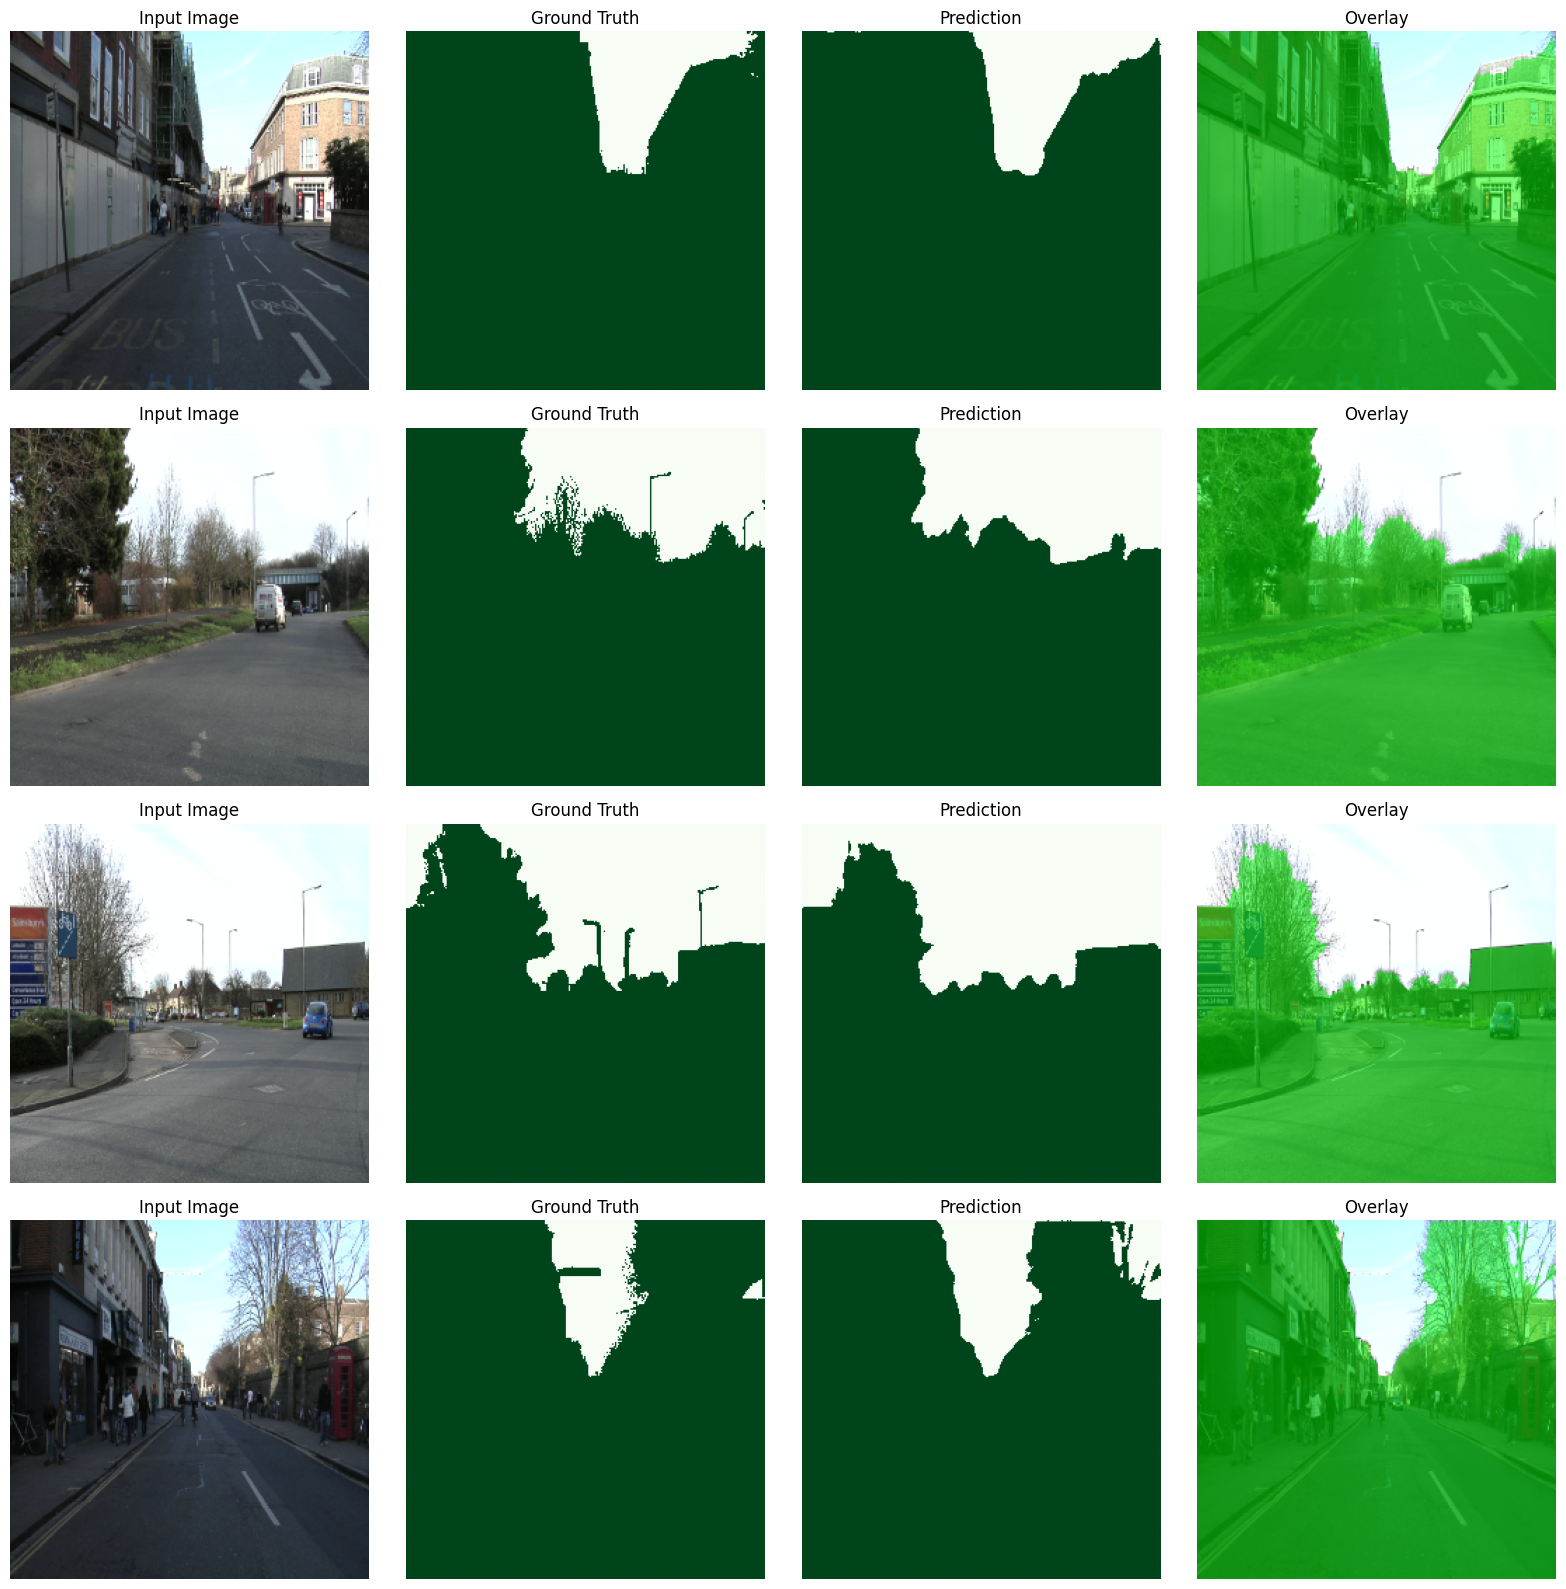

In [90]:
def visualize_predictions(model, dataset, device, n_samples=4):
    """Visualize model predictions"""
    model.eval()

    indices = np.random.choice(len(dataset), n_samples, replace=False)

    fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4*n_samples))

    for i, idx in enumerate(indices):
        image, mask = dataset[idx]

        with torch.no_grad():
            pred = model(image.unsqueeze(0).to(device))
            pred = torch.sigmoid(pred).cpu().squeeze()

        # Denormalize image for display
        img_display = image.permute(1, 2, 0).numpy()
        img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_display = np.clip(img_display, 0, 1)

        mask_display = mask.squeeze().numpy()
        pred_display = pred.numpy()
        pred_binary = (pred_display > 0.7).astype(float)

        # Original image
        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title('Input Image')
        axes[i, 0].axis('off')

        # Ground truth
        axes[i, 1].imshow(mask_display, cmap='Greens', vmin=0, vmax=1)
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')

        # Prediction
        axes[i, 2].imshow(pred_binary, cmap='Greens', vmin=0, vmax=1)
        axes[i, 2].set_title('Prediction')
        axes[i, 2].axis('off')

        # Overlay
        overlay = img_display.copy()
        overlay[pred_binary > 0.5] = overlay[pred_binary > 0.5] * 0.5 + np.array([0, 1, 0]) * 0.5
        axes[i, 3].imshow(overlay)
        axes[i, 3].set_title('Overlay')
        axes[i, 3].axis('off')

    plt.tight_layout()
    plt.show()

visualize_predictions(model, val_dataset, device, n_samples=4)

Preview: Detection + Segmentation

In [91]:
# Previewing fusion with detection model (if available)
if DETECTION_AVAILABLE:
    from ultralytics import RTDETR

    # Load detection model
    detection_model = RTDETR(detection_model_path)
    print("Detection model loaded for fusion preview!")
else:
    print("Detection model not available. Skipping fusion preview.")
    print("Run Day 60 notebook first to train the detection model.")

Detection model loaded for fusion preview!


In [96]:
def create_fusion_visualization(image_path, seg_model, det_model, device):
    """Create combined detection + segmentation visualization"""
    # Load image
    original_img = np.array(Image.open(image_path).convert('RGB'))
    h, w = original_img.shape[:2]

    # Segmentation prediction
    seg_transform = A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

    seg_input = seg_transform(image=original_img)['image'].unsqueeze(0).to(device)

    with torch.no_grad():
        seg_pred = torch.sigmoid(seg_model(seg_input)).cpu().squeeze().numpy()

    # Resize mask back to original size
    seg_mask = np.array(Image.fromarray((seg_pred * 255).astype(np.uint8)).resize((w, h))) / 255.0

    # Detection prediction
    det_results = det_model.predict(image_path, verbose=False, conf=0.25)

    # Create visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Original
    axes[0].imshow(original_img)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    # Segmentation only
    seg_overlay = original_img.copy().astype(float)
    seg_overlay[seg_mask > 0.5] = seg_overlay[seg_mask > 0.5] * 0.6 + np.array([0, 255, 0]) * 0.4
    axes[1].imshow(seg_overlay.astype(np.uint8))
    axes[1].set_title('Drivable Area (U-Net)')
    axes[1].axis('off')

    # Detection + Segmentation
    combined = seg_overlay.copy()

    # Draw detection boxes
    for box in det_results[0].boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])

        # Draw rectangle
        from matplotlib.patches import Rectangle
        rect = Rectangle((x1, y1), x2-x1, y2-y1,
                         fill=False, edgecolor='red', linewidth=2)
        axes[2].add_patch(rect)

    axes[2].imshow(combined.astype(np.uint8))
    axes[2].set_title(f'Fusion: Detection + Segmentation\n({len(det_results[0].boxes)} objects)')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

print("Fusion visualization function defined")

Fusion visualization function defined


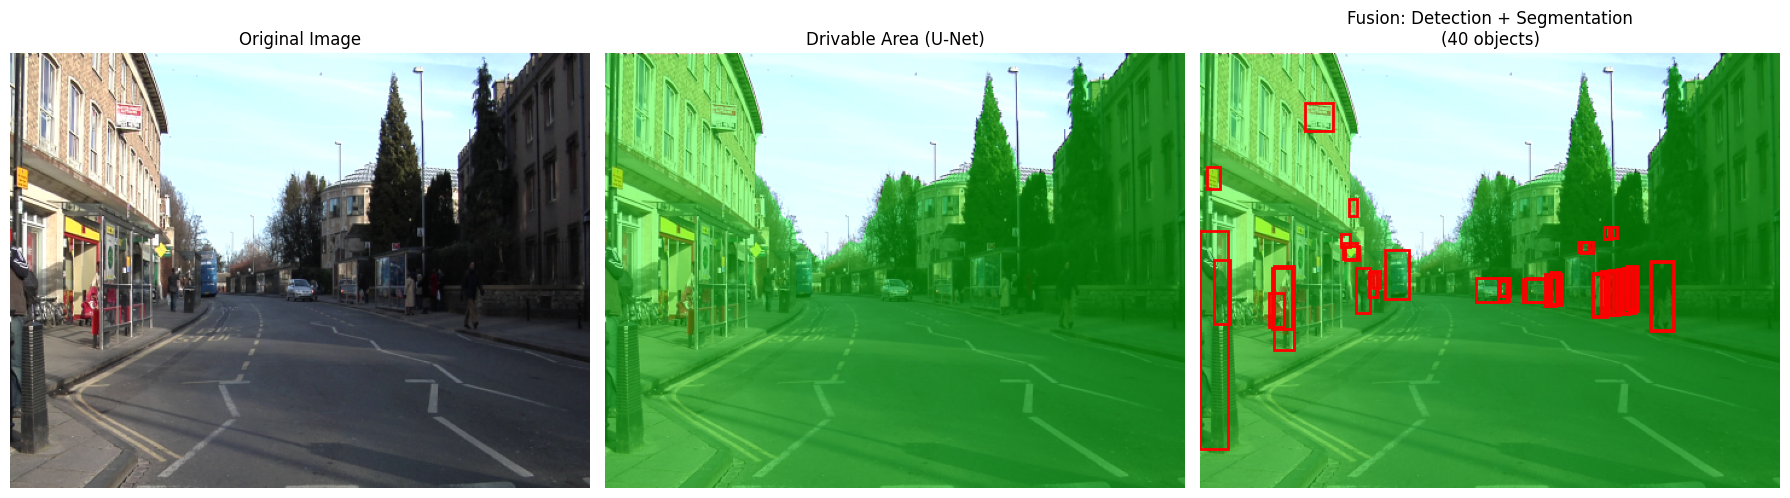

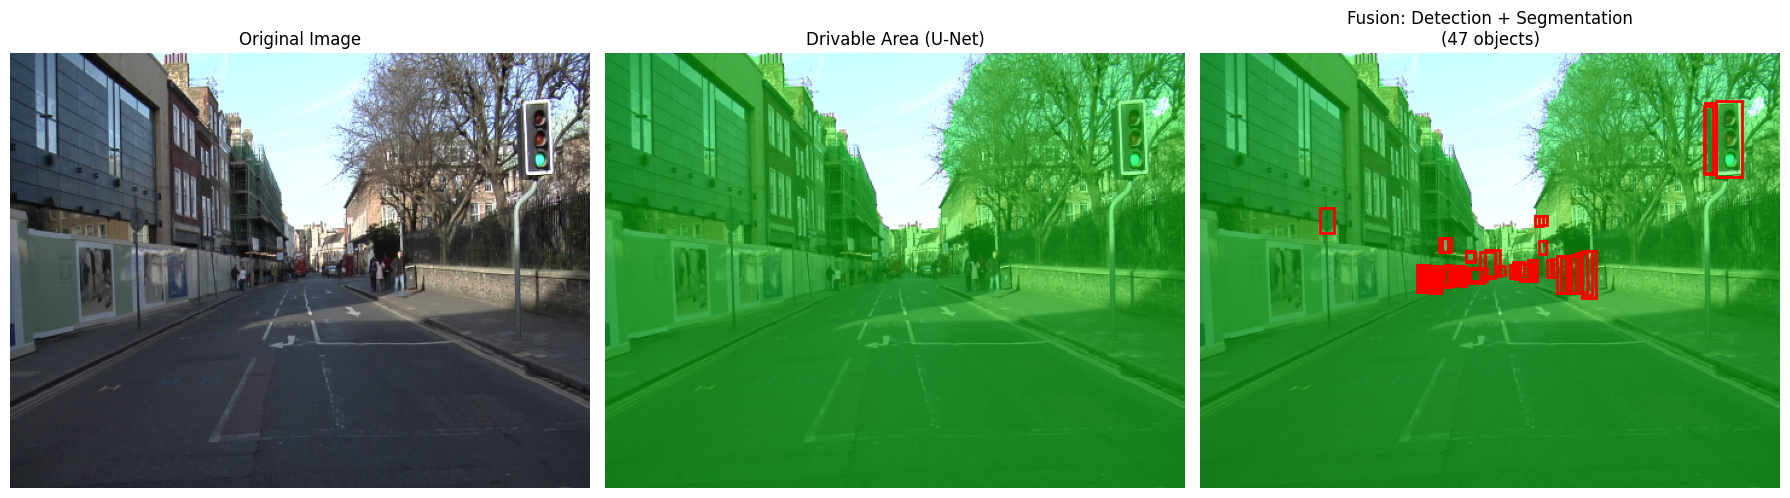

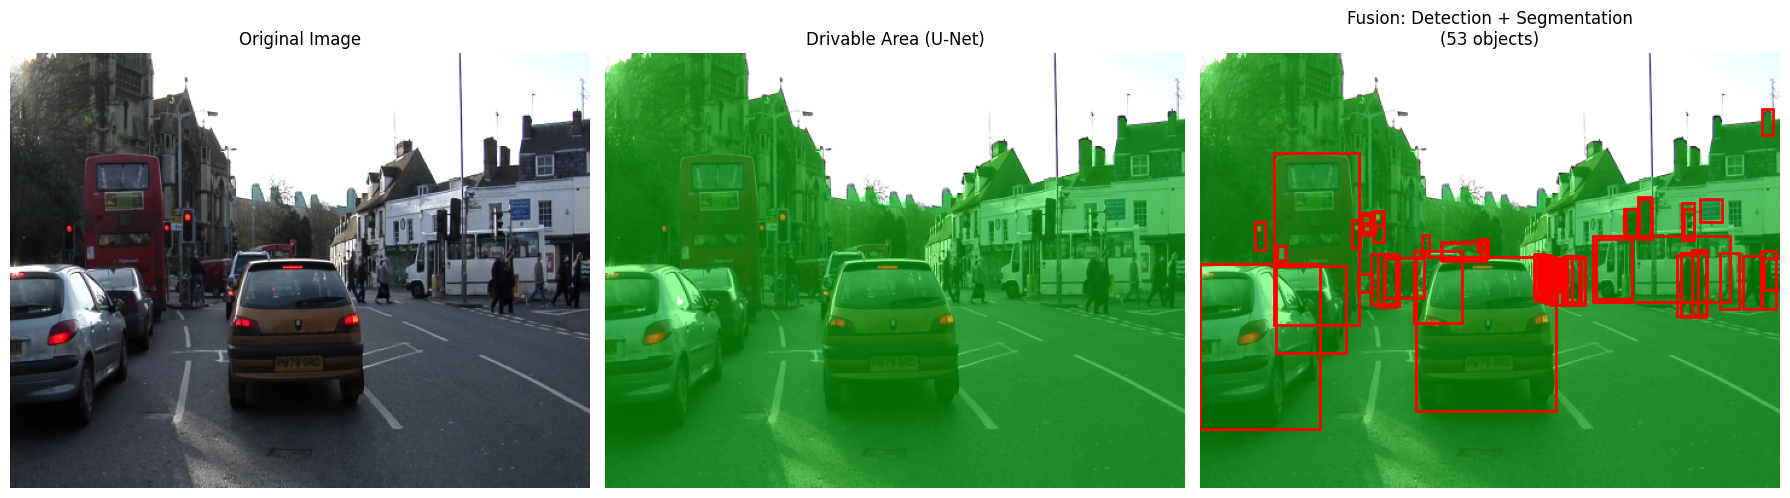

In [95]:
# Run fusion preview
if DETECTION_AVAILABLE:
    # Use validation images
    sample_images = np.random.choice(val_imgs, 3, replace=False)

    for img_path in sample_images:
        create_fusion_visualization(img_path, model, detection_model, device)
else:
    print("Skipping fusion preview - detection model not available")

In [103]:
import torch


model.eval()
model.cpu()

dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)

# Use legacy exporter explicitly
with torch.no_grad():
    torch.onnx.export(
        model,
        dummy_input,
        "/content/unet_drivable.onnx",
        export_params=True,
        opset_version=12,
        do_constant_folding=True,
        input_names=['input'],
        output_names=['output'],
        dynamo=False  # Force legacy exporter
    )

# Check size
import os
size = os.path.getsize("/content/unet_drivable.onnx") / (1024 * 1024)
print(f"ONNX size: {size:.1f} MB")

# Move model back to GPU
model.to(device)

You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
Constant folding - Only steps=1 can be constant folded for opset >= 10 onnx::Slice op. Constant folding not applied. (Triggered internally at /pytorch/torch/csrc/jit/passes/onnx/constant_fold.cpp:178.)
Constant folding - Only steps=1 can be constant folded for opset >= 10 onnx::Slice op. Constant folding not applied. (Triggered internally at /pytorch/torch/csrc/jit/passes/onnx/constant_fold.cpp:178.)


ONNX size: 118.4 MB


UNet(
  (inc): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (down): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (conv): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, t

In [106]:
# Try saving to Drive
try:
    import shutil
    shutil.copy("/content/unet_drivable.onnx", f"{SAVE_PATH}/unet_drivable.onnx")
    print("Saved to Drive!")
except Exception as e:
    print(f"Drive save failed: {e}")
    # Download to your computer instead
    from google.colab import files
    files.download("/content/unet_drivable.onnx")
    print("Downloaded to your computer")

Saved to Drive!


In [107]:
# Save .pt file too
try:
    torch.save(model.state_dict(), f"{SAVE_PATH}/unet_drivable.pt")
    print("PT saved to Drive!")
except:
    torch.save(model.state_dict(), "/content/unet_drivable.pt")
    from google.colab import files
    files.download("/content/unet_drivable.pt")
    print("PT downloaded")

PT saved to Drive!


In [105]:
# Saving artifacts
day61_artifacts = {
    'model_type': 'U-Net',
    'task': 'Drivable Area Segmentation',
    'img_size': IMG_SIZE,
    'model_path': SEGMENTATION_MODEL_PATH,
    'onnx_path': ONNX_PATH,
    'dataset_path': SEG_DATASET_PATH,
    'metrics': {
        'val_loss': val_loss,
        'val_iou': val_iou,
        'val_dice': val_dice
    }
}

with open(f"{SAVE_PATH}/day61_artifacts.json", 'w') as f:
    json.dump(day61_artifacts, f, indent=2)

print("Day 61 artifacts saved!")
print(f"\nSaved to: {SAVE_PATH}/day61_artifacts.json")

Day 61 artifacts saved!

Saved to: /content/drive/MyDrive/100-days-of-ml/capstone-autonomous-perception/day61_artifacts.json
